<a href="https://colab.research.google.com/github/Vaneelins/Vaneelins/blob/main/Climatologia_de_Santa_Catarina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install netCDF4 xarray matplotlib cartopy numpy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.1 MB/s eta 0:00:00


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from google.colab import drive #para logar no drive

# Carregar o arquivo NetCDF (substitua pelo caminho do seu arquivo)
# Montar o Google Drive
drive.mount('/content/drive')

# Carregar o arquivo NetCDF
caminho_arquivo = '/content/drive/MyDrive/TCC2/Arquivotcc/1991-2020-SulAmerica.nc'
ds = xr.open_dataset(caminho_arquivo)
# Visualizar as variáveis disponíveis
print(ds)

Mounted at /content/drive
<xarray.Dataset> Size: 93MB
Dimensions:     (valid_time: 360, latitude: 269, longitude: 241)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1991-01-01T06:00:00 ... 2020-...
  * latitude    (latitude) float64 2kB 12.0 11.75 11.5 ... -54.5 -54.75 -55.0
  * longitude   (longitude) float64 2kB -80.0 -79.75 -79.5 ... -20.25 -20.0
    number      int64 8B ...
    expver      (valid_time) <U4 6kB ...
Data variables:
    tcslw       (valid_time, latitude, longitude) float32 93MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts


In [ ]:
# 1. Definir os limites geográficos de Santa Catarina (aproximados)
lat_min, lat_max = -29.9, -24.9
lon_min, lon_max = -54.9, -48.0

# 2. Selecionar apenas os dados para Santa Catarina
dados_sc= ds.sel(
    latitude=slice(lat_max, lat_min),  # Note a ordem invertida para latitude
    longitude=slice(lon_min, lon_max)
)

# 3. Média mensal climatológica para SC (agrupando por mês)
climatology_sc = dados_sc['tcslw'].groupby('valid_time.month').mean(dim='valid_time')

# 4. Anomalias em relação à climatologia para SC
anomalies_sc = dados_sc['tcslw'].groupby('valid_time.month') - climatology_sc

# 5. Média espacial sobre Santa Catarina para análise temporal
ts_mean_sc = dados_sc['tcslw'].mean(dim=['latitude', 'longitude'])

# 6. Converter para DataFrame do Pandas
df_sc = ts_mean_sc.to_dataframe(name='tcslw').reset_index()

# 7. Verificar e limpar os dados
print(df_sc.dtypes)
print(df_sc.head())

# 8. Garantir que a coluna 'tcslw' é numérica
df_sc['tcslw'] = pd.to_numeric(df_sc['tcslw'], errors='coerce')

# 9. Remover valores NaN
df_sc = df_sc.dropna(subset=['tcslw'])

# 10. Calcular média anual para Santa Catarina
df_sc['year'] = df_sc['valid_time'].dt.year
annual_mean_sc = df_sc.groupby('year')['tcslw'].mean()

# Verificar o resultado
print(annual_mean_sc.head())

valid_time    datetime64[ns]
number                 int64
expver                object
tcslw                float32
dtype: object
           valid_time  number expver     tcslw
0 1991-01-01 06:00:00       0   0001  0.017964
1 1991-02-01 06:00:00       0   0001  0.014663
2 1991-03-01 06:00:00       0   0001  0.014207
3 1991-04-01 06:00:00       0   0001  0.015275
4 1991-05-01 06:00:00       0   0001  0.011258
year
1991    0.017686
1992    0.020863
1993    0.021173
1994    0.019045
1995    0.021974
Name: tcslw, dtype: float32


Dados utilizados para a tendência:
Anos: [1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004
 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018
 2019 2020]
Valores: [0.01768623 0.0208632  0.0211726  0.0190452  0.0219738  0.02091918
 0.02037918 0.02207731 0.01955911 0.01970938 0.0202525  0.01910456
 0.01659513 0.01977389 0.01980721 0.0167179  0.02116992 0.02206335
 0.02109667 0.02401478 0.02357851 0.01930818 0.02017172 0.01935141
 0.02196372 0.01957131 0.01901027 0.01960887 0.01867194 0.01851404]

Estatísticas da regressão:
Inclinação: -0.00001
Intercepto: 0.03626
R²: 0.00168
Valor-p: 0.82964


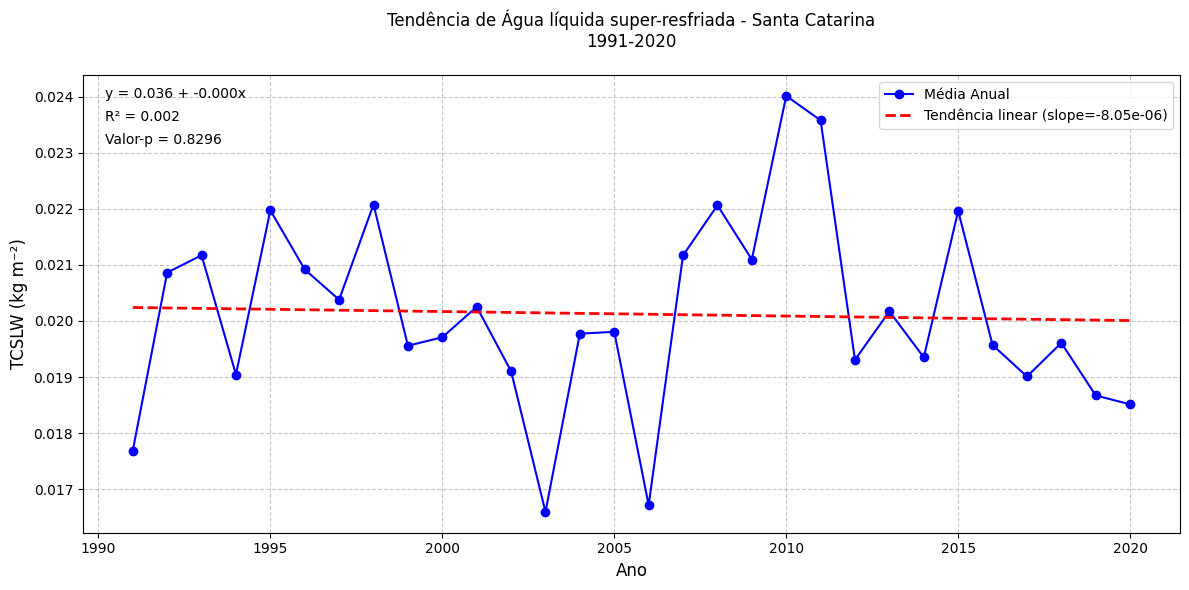

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Verificação dos dados
print("Dados utilizados para a tendência:")
print(f"Anos: {annual_mean_sc.index.values}")
print(f"Valores: {annual_mean_sc.values}")

# Garantir que os dados são numéricos
years = annual_mean_sc.index.astype(float)  # Converter anos para float
values = annual_mean_sc.astype(float)       # Garantir que valores são float

# Cálculo da regressão linear com verificação
slope, intercept, r_value, p_value, std_err = linregress(years, values)
print(f"\nEstatísticas da regressão:")
print(f"Inclinação: {slope:.5f}")
print(f"Intercepto: {intercept:.5f}")
print(f"R²: {r_value**2:.5f}")
print(f"Valor-p: {p_value:.5f}")

# Criar figura
plt.figure(figsize=(12, 6))

# Plot dos dados originais
plt.plot(years, values, 'bo-', label='Média Anual')

# Plot da linha de tendência
trend_line = intercept + slope * years
plt.plot(years, trend_line, 'r--', linewidth=2, label=f'Tendência linear (slope={slope:.2e})')

# Ajustes do gráfico
plt.title('Tendência de Água líquida super-resfriada - Santa Catarina\n1991-2020', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('TCSLW (kg m⁻²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)

# Adicionar informações da regressão
plt.text(0.02, 0.95, f'y = {intercept:.3f} + {slope:.3f}x', transform=plt.gca().transAxes)
plt.text(0.02, 0.90, f'R² = {r_value**2:.3f}', transform=plt.gca().transAxes)
plt.text(0.02, 0.85, f'Valor-p = {p_value:.4f}', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

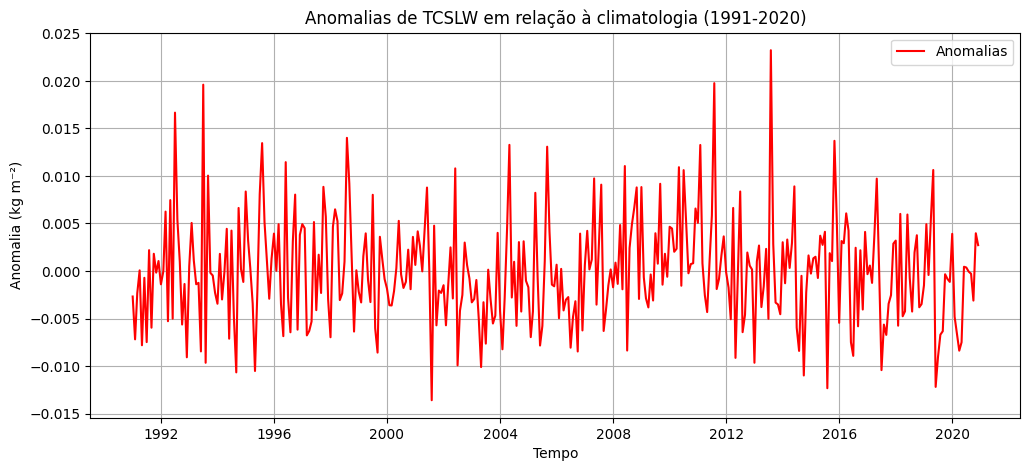

In [ ]:
plt.figure(figsize=(12, 5))
anomalies_sc.mean(dim=['latitude', 'longitude']).plot(color='red', label='Anomalias')
plt.title('Anomalias de TCSLW em relação à climatologia (1991-2020)')
plt.xlabel('Tempo')
plt.ylabel('Anomalia (kg m⁻²)')
plt.grid(True)
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


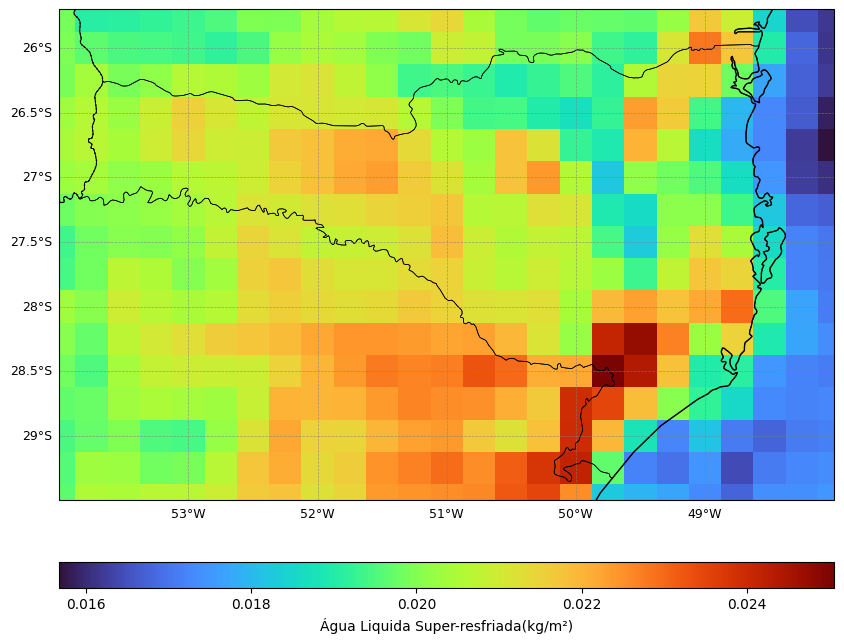

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


# Média da climatologia mensal
mean_tcs = climatology_sc.mean(dim='month')

# Cria a figura
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plotar diretamente a média climatológica
plot = mean_tcs.plot(
    ax=ax,
    cmap='turbo',
    add_colorbar=True,
    cbar_kwargs={
        'label': 'Água Liquida Super-resfriada(kg/m²)',
        'orientation': 'horizontal',   # <<< AQUI DEIXA A BARRA HORIZONTAL
        'pad': 0.10,                   # distância entre mapa e barra
        'fraction': 0.05,              # tamanho da barra (ajuste como quiser)
        'aspect': 30                   # deixa a barra mais fina/longa
    },
    transform=ccrs.PlateCarree()
)

# Adiciona feições do mapa
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)

# Recorte para Santa Catarina
ax.set_extent([-54, -48.0, -29.5, -25.7], crs=ccrs.PlateCarree())

# Adiciona linhas de latitude e longitude com rótulos
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}

# Formatação correta dos rótulos de coordenadas
import cartopy.mpl.ticker as cticker
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()

# Título do gráfico
ax.set_title('', fontsize=14)

plt.show()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


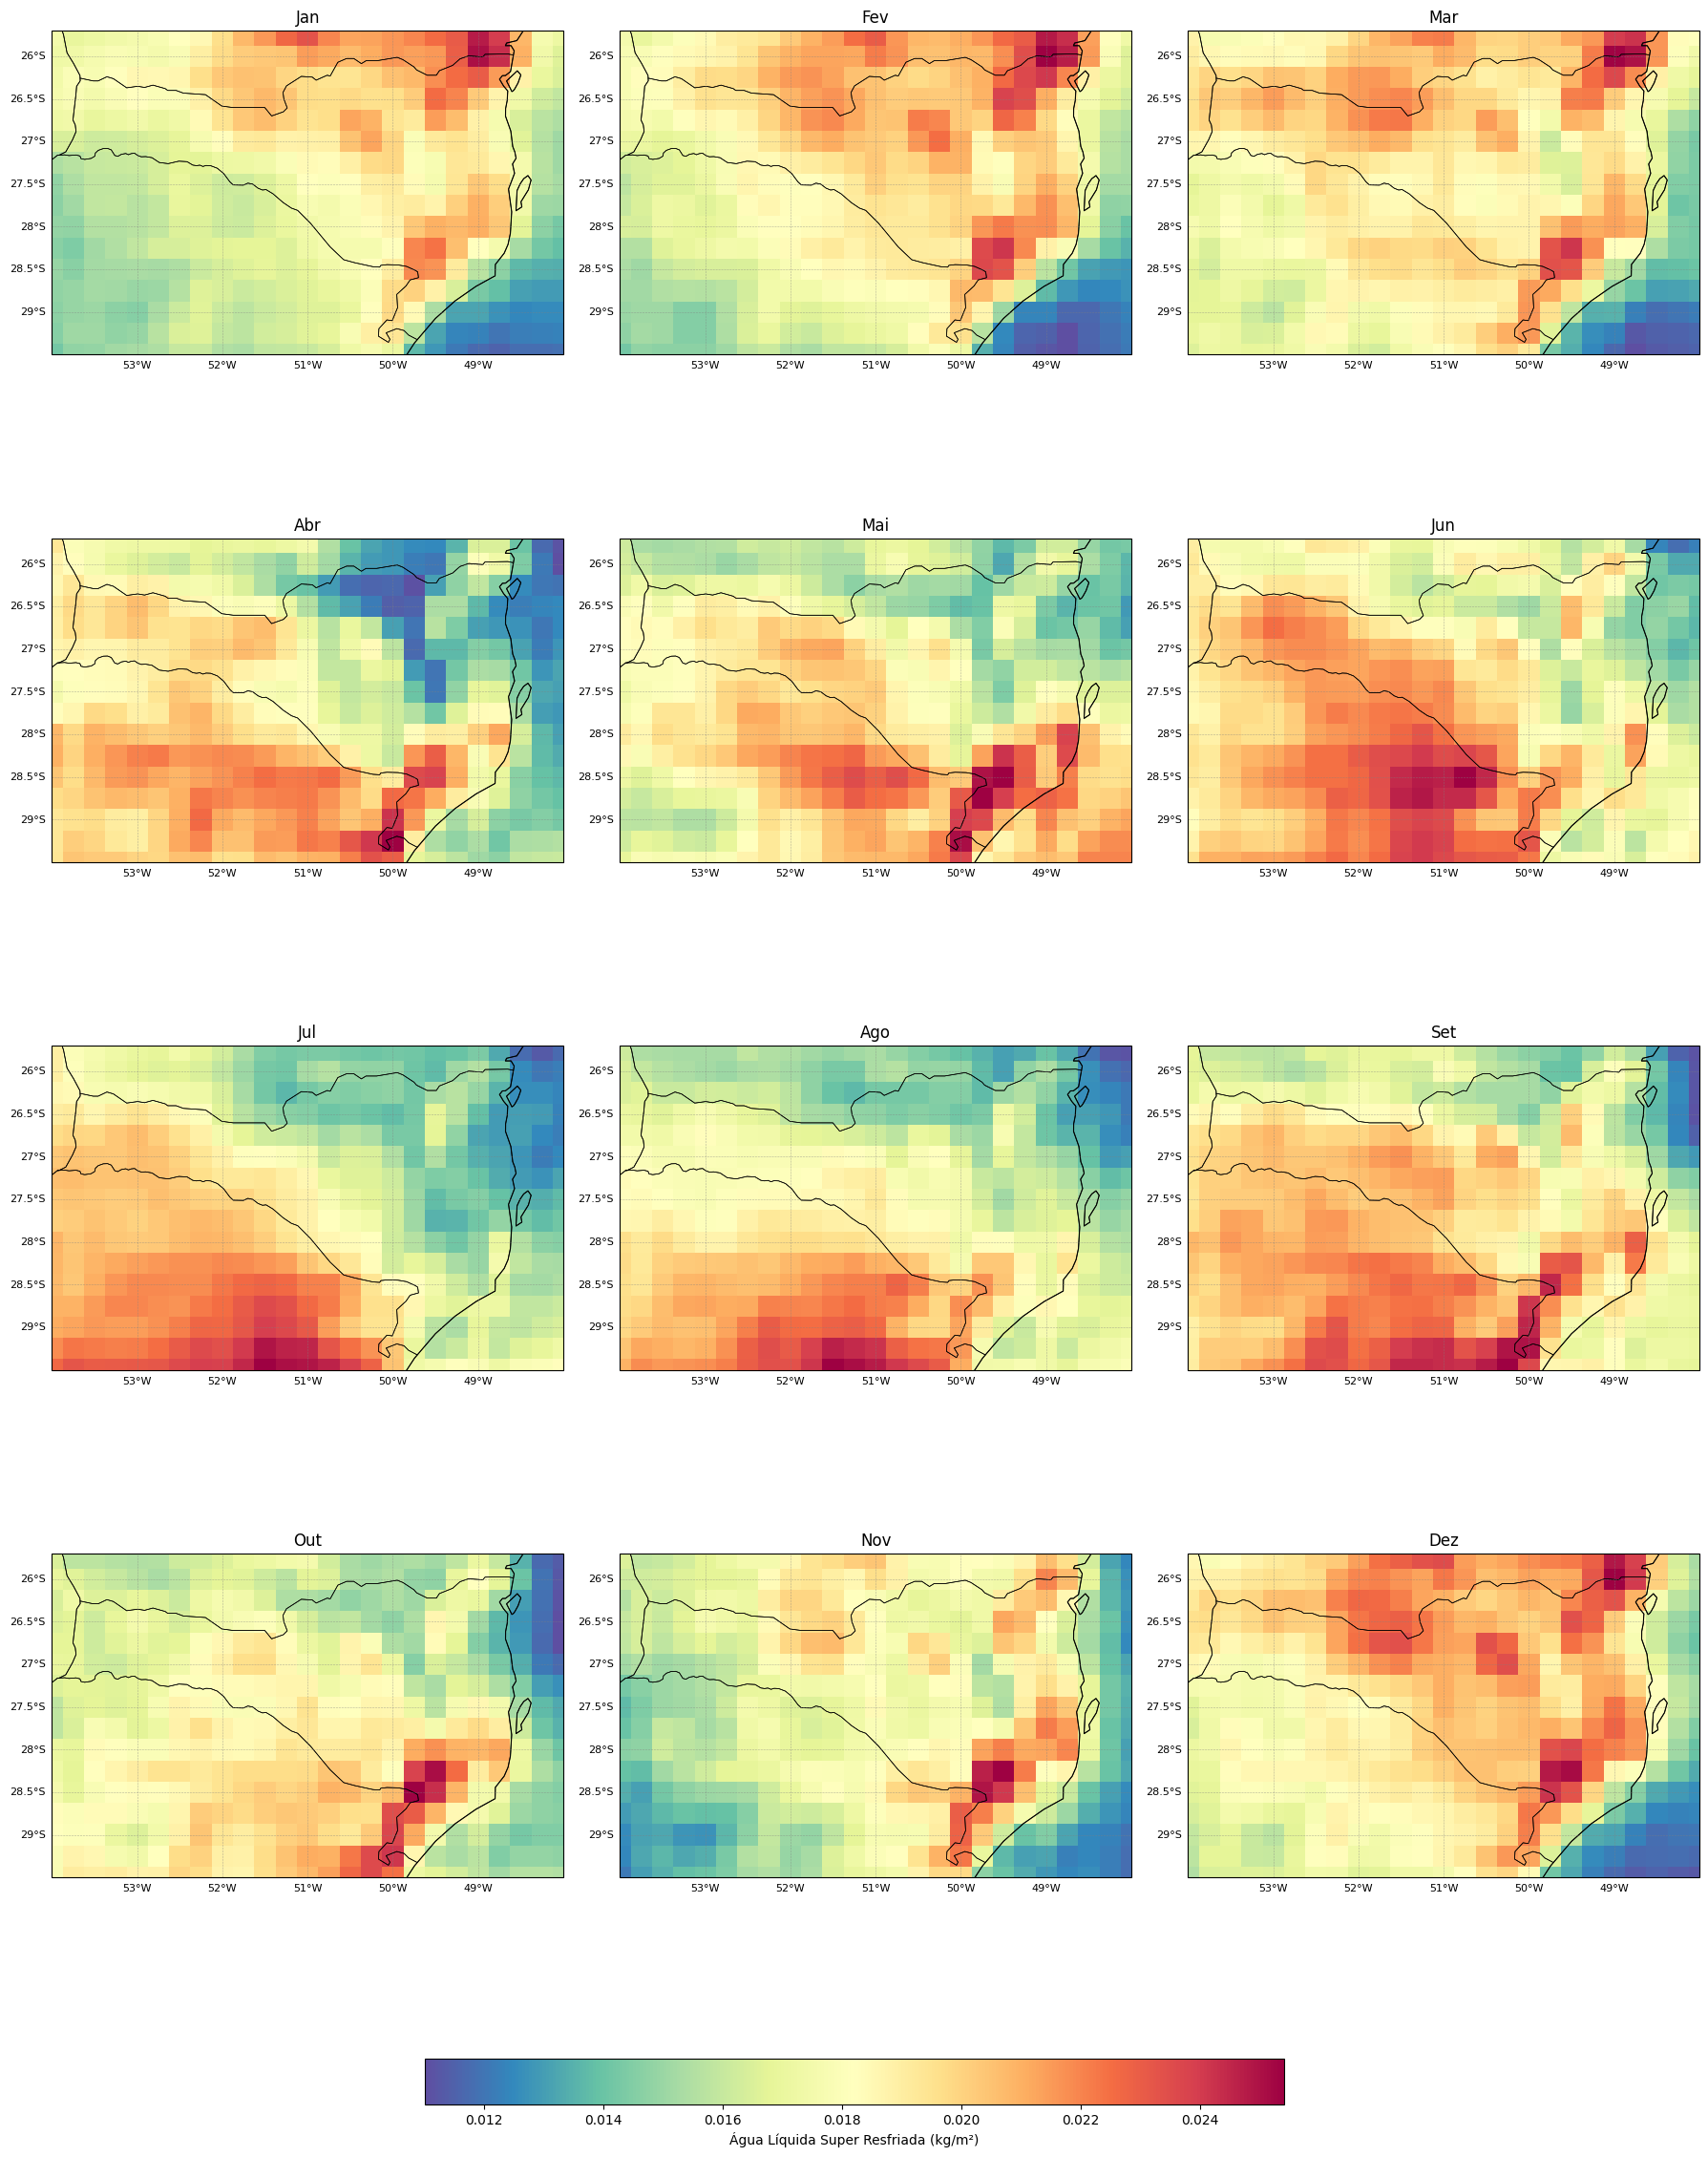

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ============================================
# 1. MÉDIA MENSAL (dados puros, sem máscara)
# ============================================

media_mensal = dados_sc['tcslw'].groupby('valid_time.month').mean(dim='valid_time')

lat = media_mensal.latitude
lon = media_mensal.longitude

# ============================================
# 2. MOSAICO
# ============================================

fig, axs = plt.subplots(
    4, 3,
    figsize=(18, 24),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig.subplots_adjust(top=0.92)
fig.suptitle('',
             fontsize=18, fontweight='bold')

# ============================================
# 3. LOOP DOS 12 MESES — DADOS ORIGINAIS
# ============================================

for i, ax in enumerate(axs.flat):

    p = media_mensal.sel(month=i+1).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='Spectral_r',
        add_colorbar=False
    )

    ax.set_title(meses[i], fontsize=12)

    # Recorte para Santa Catarina
    ax.set_extent([-54, -48.0, -29.5, -25.7], crs=ccrs.PlateCarree())

    # Feições de mapa
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.6)
    ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

# ============================================
# 4. BARRA DE CORES HORIZONTAL
# ============================================

plt.tight_layout(rect=[0, 0.05, 1, 1])

cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.02])
cb = plt.colorbar(p, cax=cbar_ax, orientation='horizontal')
cb.set_label('Água Líquida Super Resfriada (kg/m²)')

plt.show()


In [ ]:
#Para Climatologia Mensal - Biblioteca para eu fazer apenas as coordenadas de santa Catarina
!pip install geopandas shapely rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 62.0 MB/s eta 0:00:00


In [ ]:
#importando as bibliotecas
import geopandas as gpd
import xarray as xr
import rioxarray
from shapely.geometry import mapping
import os

In [ ]:
from google.colab import drive #para logar no drive
# Carregar o arquivo de Malhas (substitua pelo caminho do seu arquivo)
# Montar o Google Drive
drive.mount('/content/drive')

# Carregar o arquivo de Malhas
shapefile_path = '/content/drive/MyDrive/Malhas_UF/BR_UF_2024.shp'
estados = gpd.read_file(shapefile_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(estados.columns)

Index(['CD_UF', 'NM_UF', 'SIGLA_UF', 'CD_REGIA', 'NM_REGIA', 'SIGLA_RG',
       'AREA_KM2', 'geometry'],
      dtype='object')


In [ ]:

# Filtra Santa Catarina (ajuste se a coluna de nome for diferente)
sc = estados[estados['NM_UF'] == 'Santa Catarina']

# Garante que está no sistema de coordenadas certo (WGS84)
sc = sc.to_crs("EPSG:4326")

In [ ]:
# Garante que o dataset tem sistema de coordenadas definido
dados_sc.rio.write_crs("EPSG:4326", inplace=True)

# Faz o recorte usando o shapefile de SC
dados_sc_recortado = dados_sc.rio.clip(sc.geometry, sc.crs, drop=True, invert=False)

In [ ]:

tcslw_mensal = dados_sc_recortado['tcslw'].groupby('valid_time.month')

valores_mensais = [
    dados_sc_recortado['tcslw'].isel(valid_time=tcslw_mensal.groups[m]).values.flatten()
    for m in range(1, 13)
]
valores_mensais = [v[~np.isnan(v)] for v in valores_mensais]

medias = [v.mean() for v in valores_mensais]
stds = [v.std() for v in valores_mensais]
dp_sazonal = np.std(medias)

/tmp/ipython-input-3315921924.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


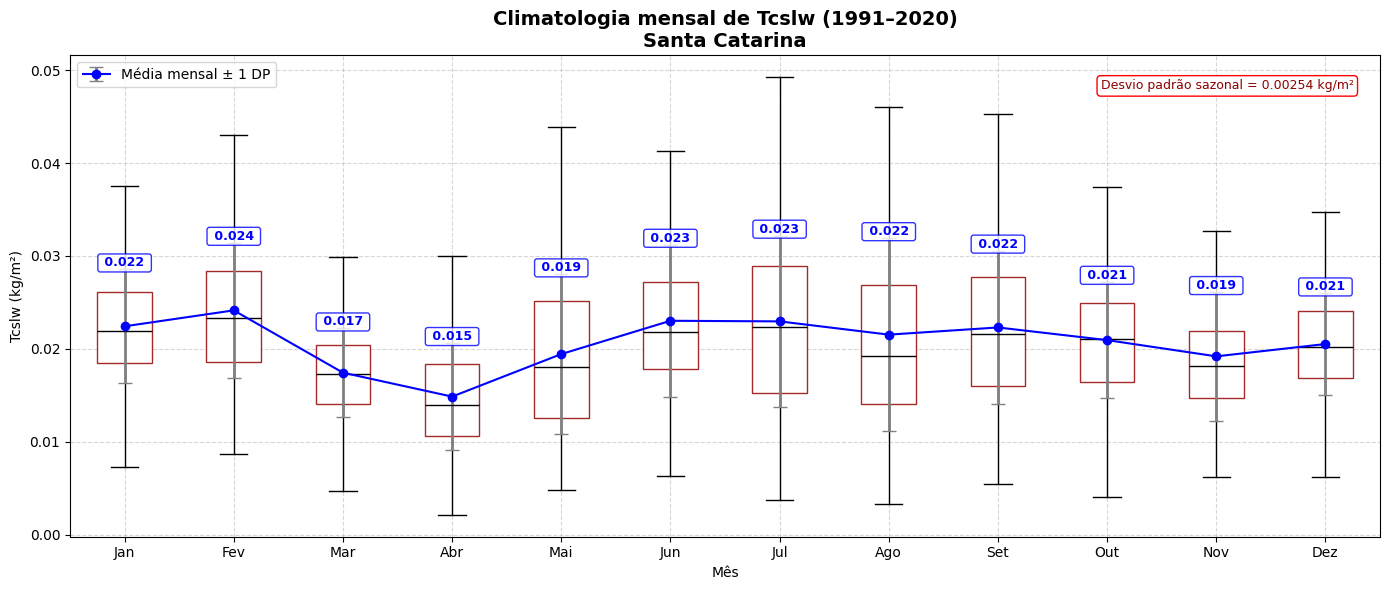

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Dados já preparados ---
# valores_mensais: lista com 12 arrays (um para cada mês, só com valores de Santa Catarina)
# medias: média de cada mês
# stds: desvio padrão de cada mês
# dp_sazonal: desvio padrão sazonal entre as médias mensais
# meses: lista com nomes dos meses

fig, ax = plt.subplots(figsize=(14, 6))

# Boxplot sem outliers (showfliers=False)
ax.boxplot(
    valores_mensais, labels=meses, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor='white', color='brown'),
    medianprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

ax.errorbar(
    range(1, 13), medias, yerr=stds,
    fmt='o-', color='blue', ecolor='gray',
    elinewidth=2, capsize=5, label='Média mensal ± 1 DP'
)

for i, (media, std) in enumerate(zip(medias, stds)):
    # Configuração do quadro de texto
    ax.text(
        i + 1,                  # Posição X (mês)
        media + std - 0.000,   # Posição Y (acima da barra de erro)
        f' {media:.3f} ',       # Texto com espaços para margem
        fontsize=9,
        ha='center',
        va='bottom',
        color='blue',
        weight='bold',
        bbox=dict(              # Caixa personalizada
            facecolor='white',
            edgecolor='blue',
            boxstyle='round,pad=0.2',
            alpha=0.8
        )
    )


# Título e rótulos
ax.set_title('Climatologia mensal de Tcslw (1991–2020)\nSanta Catarina', fontsize=14, weight='bold')
ax.set_ylabel('Tcslw (kg/m²)')
ax.set_xlabel('Mês')
ax.grid(True, linestyle='--', alpha=0.5)

# Anotação do desvio padrão sazonal
ax.text(0.98, 0.95,
        f'Desvio padrão sazonal = {dp_sazonal:.5f} kg/m²',
        transform=ax.transAxes,
        fontsize=9, color='darkred',
        horizontalalignment='right',
        verticalalignment='top',
        bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3'))

# Legenda
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Agrupar os dados por mês
tcslw_mensal = dados_sc_recortado['tcslw'].groupby('valid_time.month')

# Calcular a média mensal (média espacial e temporal por mês)
media_mensal_por_mes = [
    dados_sc_recortado['tcslw'].isel(valid_time=tcslw_mensal.groups[m]).mean().item()
    for m in range(1, 13)
]

# Exibir resultados com os nomes dos meses
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

for m, valor in zip(meses, media_mensal_por_mes):
    print(f'{m}: {valor:.5f} kg/m²')

Jan: 0.02243 kg/m²
Fev: 0.02414 kg/m²
Mar: 0.01744 kg/m²
Abr: 0.01486 kg/m²
Mai: 0.01944 kg/m²
Jun: 0.02302 kg/m²
Jul: 0.02296 kg/m²
Ago: 0.02153 kg/m²
Set: 0.02230 kg/m²
Out: 0.02094 kg/m²
Nov: 0.01920 kg/m²
Dez: 0.02052 kg/m²


In [ ]:
minimos = [np.min(v) for v in valores_mensais]
maximos = [np.max(v) for v in valores_mensais]

for mes, min_v, max_v in zip(meses, minimos, maximos):
    print(f'{mes}: Mínimo = {min_v:.3f}, Máximo = {max_v:.3f}')

Jan: Mínimo = 0.007, Máximo = 0.049
Fev: Mínimo = 0.009, Máximo = 0.058
Mar: Mínimo = 0.003, Máximo = 0.042
Abr: Mínimo = 0.002, Máximo = 0.035
Mai: Mínimo = 0.005, Máximo = 0.055
Jun: Mínimo = 0.006, Máximo = 0.057
Jul: Mínimo = 0.004, Máximo = 0.059
Ago: Mínimo = 0.003, Máximo = 0.073
Set: Mínimo = 0.005, Máximo = 0.054
Out: Mínimo = 0.004, Máximo = 0.049
Nov: Mínimo = 0.006, Máximo = 0.097
Dez: Mínimo = 0.005, Máximo = 0.042


In [ ]:
q1s = [np.percentile(v, 25) for v in valores_mensais]
q3s = [np.percentile(v, 75) for v in valores_mensais]

for mes, q1, q3 in zip(meses, q1s, q3s):
    print(f'{mes}: Q1 = {q1:.3f}, Q3 = {q3:.3f}')

Jan: Q1 = 0.019, Q3 = 0.026
Fev: Q1 = 0.019, Q3 = 0.028
Mar: Q1 = 0.014, Q3 = 0.020
Abr: Q1 = 0.011, Q3 = 0.018
Mai: Q1 = 0.013, Q3 = 0.025
Jun: Q1 = 0.018, Q3 = 0.027
Jul: Q1 = 0.015, Q3 = 0.029
Ago: Q1 = 0.014, Q3 = 0.027
Set: Q1 = 0.016, Q3 = 0.028
Out: Q1 = 0.016, Q3 = 0.025
Nov: Q1 = 0.015, Q3 = 0.022
Dez: Q1 = 0.017, Q3 = 0.024


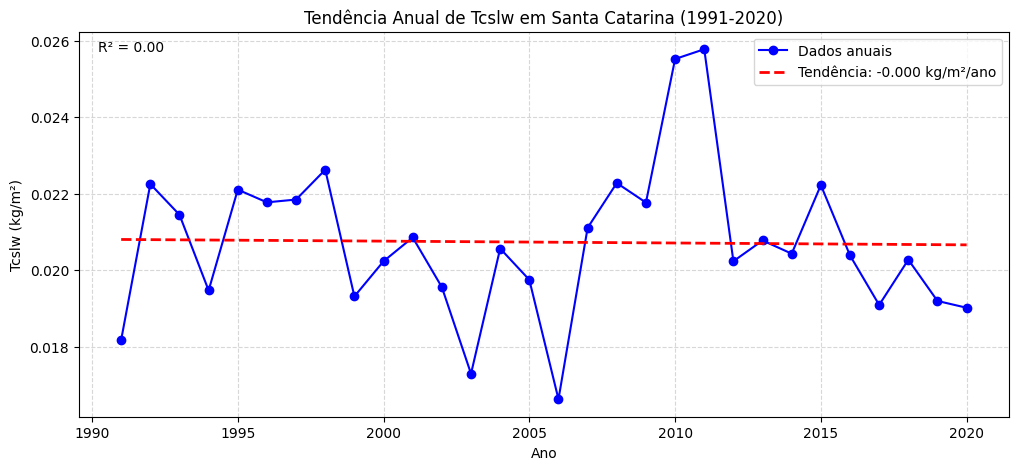

In [ ]:
# 1. Calcular a média anual (agrupar por ano)
tendencia_anual = dados_sc_recortado['tcslw'].mean(dim=['latitude', 'longitude']).groupby('valid_time.year').mean()

# 2. Extrair anos e valores
anos = tendencia_anual.year.values
valores = tendencia_anual.values

# 3. Calcular tendência linear (usando anos completos)
coef = np.polyfit(anos, valores, deg=1)
tendencia_linear = np.poly1d(coef)

# 4. Plotar
plt.figure(figsize=(12, 5))

# Dados anuais
plt.plot(anos, valores, 'bo-', label='Dados anuais')

# Linha de tendência
plt.plot(anos, tendencia_linear(anos), 'r--', linewidth=2,
         label=f'Tendência: {coef[0]:.3f} kg/m²/ano')

# Detalhes do gráfico
plt.title('Tendência Anual de Tcslw em Santa Catarina (1991-2020)')
plt.ylabel('Tcslw (kg/m²)')
plt.xlabel('Ano')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Mostrar estatísticas
r_squared = np.corrcoef(anos, valores)[0, 1]**2
plt.text(0.02, 0.95, f'R² = {r_squared:.2f}', transform=plt.gca().transAxes)

plt.show()

In [ ]:
print(dados_sc_recortado['tcslw'].mean(dim=['latitude', 'longitude']))

<xarray.DataArray 'tcslw' (valid_time: 360)> Size: 1kB
array([0.01946403, 0.01617493, 0.01548327, 0.01458595, 0.01060096,
       0.02489936, 0.01373734, 0.02672404, 0.01481105, 0.02147619,
       0.01875748, 0.02144367, 0.02132959, 0.02310582, 0.02426147,
       0.00802292, 0.03308317, 0.01971099, 0.03882858, 0.03300117,
       0.02329945, 0.01492298, 0.01718889, 0.01026268, 0.02184936,
       0.03303313, 0.01687335, 0.01608079, 0.01748977, 0.01270269,
       0.0409038 , 0.01190316, 0.03339848, 0.01924317, 0.01626617,
       0.01763353, 0.01768533, 0.02485412, 0.01455546, 0.01340554,
       0.02300095, 0.01833385, 0.02743653, 0.01511135, 0.00945505,
       0.0281626 , 0.0205772 , 0.02106075, 0.03130335, 0.02750402,
       0.01653011, 0.0122087 , 0.00849644, 0.02191354, 0.02736541,
       0.03062024, 0.02521053, 0.02500236, 0.0171347 , 0.02197302,
       0.02610651, 0.02251877, 0.02252559, 0.01039563, 0.01310206,
       0.04021877, 0.02203124, 0.01409545, 0.02852903, 0.02430316,
       

In [ ]:
print(np.unique(dados_sc_recortado['valid_time'].dt.year))

[1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004
 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018
 2019 2020]


In [ ]:
anos = tendencia_anual.year.values
valores = tendencia_anual.values
anos_norm = (anos - anos.min())  # Normalização simples
coef = np.polyfit(anos_norm, valores, deg=1)
print(f"Tendência: {coef[0]} kg/m²/ano")

Tendência: -4.858371943600411e-06 kg/m²/ano


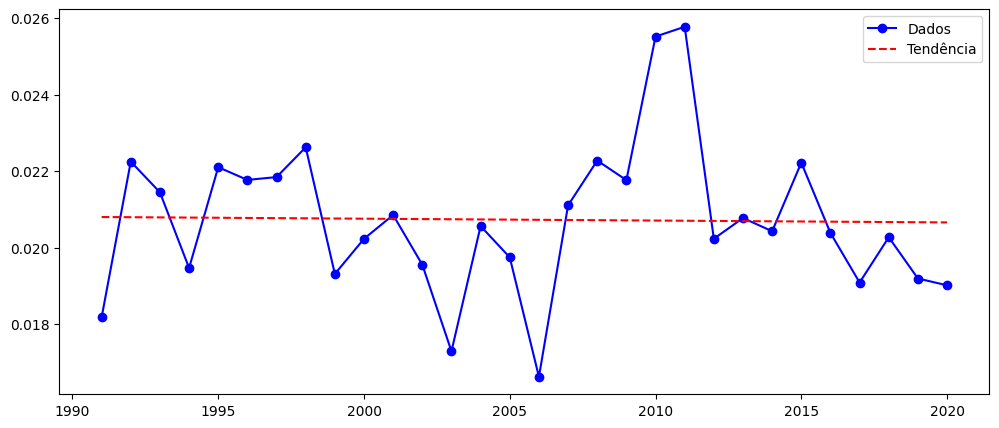

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(anos, valores, 'bo-', label='Dados')
plt.plot(anos, np.poly1d(coef)(anos_norm), 'r--', label='Tendência')
plt.legend()
plt.show()

In [ ]:
print(f"""
Média: {tendencia_anual.mean().values:.6f} kg/m²
Desvio padrão: {tendencia_anual.std().values:.6f} kg/m²
Variação total (1991-2020): {(tendencia_anual[-1] - tendencia_anual[0]).values:.6f} kg/m²
""")


Média: 0.020732 kg/m²
Desvio padrão: 0.001957 kg/m²
Variação total (1991-2020): 0.000838 kg/m²

